# 🔧 Day 3 — Transformers & Architecture: Build Your Own Mini Thai LLM
### Generative AI using Python 2026

**Run on:** Google Colab (free T4 GPU) or Kaggle (T4×2 free)

In this notebook you will implement **every component** of a modern decoder-only Transformer from scratch — the same architecture used by Llama 4 and Typhoon 2, just much smaller. Then train it on Thai text and watch it generate Thai characters.

| Module | Topic |
|--------|-------|
| M7 | Scaled dot-product attention (NumPy → PyTorch) |
| M7 | Causal mask & multi-head attention |
| M7 | RoPE positional encoding |
| M8 | RMSNorm, SwiGLU FFN, Transformer Block |
| M8 | Complete MiniLLM + training on Thai Wikipedia |
| M8 | Architecture experiments |
| M9 | Vision Transformer (ViT) concepts |

> **Estimated time:** ~3 hours | **GPU needed:** Yes (for training — T4 free on Colab is fine)


## ⚙️ 0 — Setup & GPU Check

In [1]:
# Check GPU
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    print(f"VRAM:            {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU — training will be slow (reduce steps to 500)")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nUsing device: {DEVICE}")


PyTorch version: 2.10.0+cu128
CUDA available:  True
GPU:             Tesla T4
VRAM:            15.6 GB

Using device: cuda


In [2]:
# All imports
import math
import time
import urllib.request
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

print("All imports OK ✓")


All imports OK ✓


---
## Module 7 — Attention from Scratch

### 7.1 Scaled Dot-Product Attention in NumPy

We start in NumPy so you can see every matrix operation without framework magic.

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- **Q** (Query): "What am I looking for?"
- **K** (Key):   "What do I contain?"
- **V** (Value): "What do I contribute?"
- **√dₖ**: prevents dot products growing too large → softmax saturation


In [3]:
def softmax_np(x: np.ndarray, axis: int = -1) -> np.ndarray:
    """Numerically stable softmax."""
    x = x - x.max(axis=axis, keepdims=True)   # subtract max for stability
    ex = np.exp(x)
    return ex / ex.sum(axis=axis, keepdims=True)


def attention_numpy(Q, K, V, mask=None):
    """
    Scaled dot-product attention.
    Q, K: (seq_len, d_k)
    V:    (seq_len, d_v)
    Returns: (output, attention_weights)
    """
    d_k    = Q.shape[-1]
    scores = Q @ K.T / math.sqrt(d_k)   # (seq_len, seq_len)
    if mask is not None:
        scores = scores + mask
    weights = softmax_np(scores)
    output  = weights @ V
    return output, weights


# ── Toy demo ──
np.random.seed(42)
seq_len, d_k = 4, 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

output, weights = attention_numpy(Q, K, V)
print(f"Output shape:  {output.shape}")
print(f"\nAttention weights (each row sums to 1.0):")
print(weights.round(3))
print(f"\nRow sums: {weights.sum(axis=-1).round(6)}")


Output shape:  (4, 8)

Attention weights (each row sums to 1.0):
[[0.084 0.255 0.515 0.145]
 [0.641 0.133 0.017 0.209]
 [0.47  0.088 0.111 0.331]
 [0.178 0.492 0.201 0.13 ]]

Row sums: [1. 1. 1. 1.]


### 7.2 The Causal Mask

In autoregressive generation, token N cannot attend to tokens N+1, N+2, … because those haven't been generated yet. We set future positions to **-∞** before softmax → they become exactly 0 after exp(-∞).

Causal mask:
[[  0. -inf -inf -inf]
 [  0.   0. -inf -inf]
 [  0.   0.   0. -inf]
 [  0.   0.   0.   0.]]

Masked weights (upper triangle is 0 — future is invisible):
[[1.    0.    0.    0.   ]
 [0.828 0.172 0.    0.   ]
 [0.702 0.131 0.166 0.   ]
 [0.178 0.492 0.201 0.13 ]]


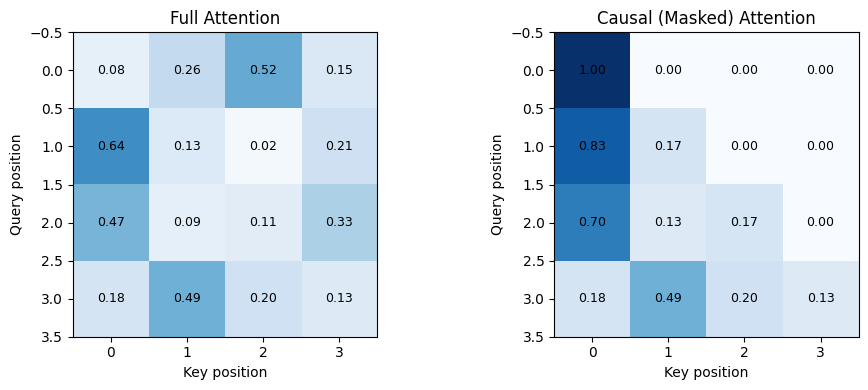

✓ Notice: row 0 can only attend to position 0 (weight=1.0)
  Row 3 can attend to all 4 positions


In [4]:
def causal_mask_np(seq_len: int) -> np.ndarray:
    """Upper-triangular -inf mask (diagonal and below = 0)."""
    return np.triu(np.full((seq_len, seq_len), -np.inf), k=1)

mask = causal_mask_np(4)
print("Causal mask:")
print(mask)

out_masked, w_masked = attention_numpy(Q, K, V, mask=mask)
print("\nMasked weights (upper triangle is 0 — future is invisible):")
print(w_masked.round(3))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(weights, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Full Attention")
axes[0].set_xlabel("Key position"); axes[0].set_ylabel("Query position")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{weights[i,j]:.2f}", ha="center", va="center", fontsize=9)

axes[1].imshow(w_masked, cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Causal (Masked) Attention")
axes[1].set_xlabel("Key position"); axes[1].set_ylabel("Query position")
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{w_masked[i,j]:.2f}", ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("attention_weights.png", dpi=100, bbox_inches="tight")
plt.show()
print("✓ Notice: row 0 can only attend to position 0 (weight=1.0)")
print("  Row 3 can attend to all 4 positions")


### 7.3 RoPE — Rotary Positional Embeddings

Used by Llama 4, Typhoon 2, Mistral. Instead of adding position to embeddings, **rotate** Q and K vectors. Key property: the dot product Q·K depends only on the **relative distance** between positions, not absolute positions.


In [5]:
def precompute_rope_freqs(d_k: int, max_seq_len: int, base: float = 10_000.0):
    """Precompute RoPE cos/sin tables. Returns (cos, sin) each (max_seq_len, d_k//2)."""
    i      = torch.arange(0, d_k, 2, dtype=torch.float32)
    thetas = 1.0 / (base ** (i / d_k))          # (d_k//2,) — frequency per dimension
    t      = torch.arange(max_seq_len, dtype=torch.float32)
    freqs  = torch.outer(t, thetas)              # (max_seq_len, d_k//2)
    return freqs.cos(), freqs.sin()


def apply_rope(x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
    """Apply RoPE rotation to Q or K. x: (B, n_heads, T, d_k)"""
    T, d_k = x.shape[-2], x.shape[-1]
    x1 = x[..., :d_k // 2]
    x2 = x[..., d_k // 2:]
    c  = cos[:T].unsqueeze(0).unsqueeze(0)   # (1, 1, T, d_k//2)
    s  = sin[:T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1 * c - x2 * s, x1 * s + x2 * c], dim=-1)


# Test
cos_f, sin_f = precompute_rope_freqs(d_k=64, max_seq_len=2048)
Q_pt = torch.randn(1, 8, 10, 64)   # (batch, heads, seq, d_k)
Q_rot = apply_rope(Q_pt, cos_f, sin_f)
print(f"Q shape unchanged: {Q_rot.shape}")
print(f"Magnitude preserved (rotation is norm-preserving):")
print(f"  Before: {Q_pt.norm():.4f}")
print(f"  After:  {Q_rot.norm():.4f}")
print("✓ RoPE works correctly")


Q shape unchanged: torch.Size([1, 8, 10, 64])
Magnitude preserved (rotation is norm-preserving):
  Before: 71.2179
  After:  71.2179
✓ RoPE works correctly


### 7.4 Multi-Head Attention in PyTorch

H heads run in parallel, each with smaller d_k = d_model/H. The efficient trick: **reshape tensors** instead of looping over heads.


In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.d_model = d_model
        # Single fused projection for Q, K, V (faster than 3 separate)
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_o   = nn.Linear(d_model, d_model,     bias=False)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        qkv = self.W_qkv(x)                        # (B, T, 3*d_model)
        Q, K, V = qkv.chunk(3, dim=-1)              # each: (B, T, d_model)

        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = split_heads(Q), split_heads(K), split_heads(V)   # (B, H, T, d_k)

        # Apply RoPE to Q and K
        Q = apply_rope(Q, cos, sin)
        K = apply_rope(K, cos, sin)

        # PyTorch 2.0+ uses FlashAttention automatically when is_causal=True
        out = F.scaled_dot_product_attention(Q, K, V, is_causal=True, dropout_p=0.0)

        # Merge heads: (B, H, T, d_k) → (B, T, d_model)
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out)


# Test shapes
mha = MultiHeadAttention(d_model=256, n_heads=8)
x_test = torch.randn(2, 10, 256)
cos_t, sin_t = precompute_rope_freqs(256 // 8, 512)
out = mha(x_test, cos_t[:10], sin_t[:10])
print(f"MHA input:  {x_test.shape}")
print(f"MHA output: {out.shape}   ← same shape as input ✓")
print(f"Parameters: {sum(p.numel() for p in mha.parameters()):,}")


MHA input:  torch.Size([2, 10, 256])
MHA output: torch.Size([2, 10, 256])   ← same shape as input ✓
Parameters: 262,144


---
## Module 8 — Building the Full Transformer Block

### 8.1 RMSNorm — Modern Normalization

All modern LLMs (Llama 4, Typhoon 2, Mistral) use **RMSNorm** instead of LayerNorm.  
Formula: `x / sqrt(mean(x²) + ε) × γ`  
No mean-centering, no shift parameter β → ~10% faster, equally effective.


In [7]:
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(d_model))   # learnable scale only

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return self.gamma * (x / rms)


# Test: output should have RMS ≈ 1.0
norm = RMSNorm(256)
x_big = torch.randn(2, 10, 256) * 100   # deliberately huge values
out = norm(x_big)
print(f"Input  RMS: {x_big.pow(2).mean().sqrt():.2f}  (large)")
print(f"Output RMS: {out.pow(2).mean().sqrt():.4f}   (normalised ≈ 1.0) ✓")


Input  RMS: 101.61  (large)
Output RMS: 1.0000   (normalised ≈ 1.0) ✓


### 8.2 SwiGLU — Modern Feed-Forward Network

Used by Llama 4, PaLM, Typhoon 2. Outperforms ReLU and GeLU on most benchmarks.

`SwiGLU(x) = SiLU(W₁x) ⊙ W₃x → W₂`

In [8]:
class SwiGLU(nn.Module):
    def __init__(self, d_model: int, d_ff: int = None, dropout: float = 0.0):
        super().__init__()
        if d_ff is None:
            d_ff = int(2 / 3 * 4 * d_model)
            d_ff = (d_ff + 63) // 64 * 64    # round to multiple of 64 (GPU efficiency)
        self.w1  = nn.Linear(d_model, d_ff, bias=False)   # gate projection
        self.w2  = nn.Linear(d_ff, d_model, bias=False)   # down projection
        self.w3  = nn.Linear(d_model, d_ff, bias=False)   # up projection
        self.drop= nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(self.w2(F.silu(self.w1(x)) * self.w3(x)))


ffn = SwiGLU(d_model=256)
x_test = torch.randn(2, 10, 256)
print(f"FFN output shape: {ffn(x_test).shape}  ✓")
print(f"FFN parameters:   {sum(p.numel() for p in ffn.parameters()):,}")


FFN output shape: torch.Size([2, 10, 256])  ✓
FFN parameters:   540,672


### 8.3 The Transformer Block

Pre-Norm architecture (normalize **before** attention/FFN, not after) — standard in all modern LLMs for training stability.

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ffn   = SwiGLU(d_model, dropout=dropout)

    def forward(self, x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
        # Pre-norm + residual connection (the "highway" for gradients)
        x = x + self.attn(self.norm1(x), cos, sin)
        x = x + self.ffn(self.norm2(x))
        return x


block = TransformerBlock(d_model=256, n_heads=8)
x_test = torch.randn(2, 10, 256)
cos_t, sin_t = precompute_rope_freqs(256 // 8, 512)
out = block(x_test, cos_t[:10], sin_t[:10])
print(f"Block input:  {x_test.shape}")
print(f"Block output: {out.shape}  ✓  (same shape — residual connection)")
print(f"Block params: {sum(p.numel() for p in block.parameters()):,}")


Block input:  torch.Size([2, 10, 256])
Block output: torch.Size([2, 10, 256])  ✓  (same shape — residual connection)
Block params: 803,328


### 8.4 The Complete Decoder-Only Language Model

In [10]:
class MiniLLM(nn.Module):
    """
    Decoder-only LM: Embedding → N×TransformerBlock → RMSNorm → LM Head
    Architecturally identical to GPT-2 / Llama (smaller scale).
    """
    def __init__(
        self,
        vocab_size: int,
        d_model:    int   = 256,
        n_layers:   int   = 6,
        n_heads:    int   = 8,
        max_seq:    int   = 512,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.embed   = nn.Embedding(vocab_size, d_model)

        # Precompute RoPE tables (not learned — stored as buffers)
        cos, sin = precompute_rope_freqs(d_model // n_heads, max_seq)
        self.register_buffer("rope_cos", cos)
        self.register_buffer("rope_sin", sin)

        self.blocks  = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.norm    = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding and output weights (reduces params, improves quality)
        self.lm_head.weight = self.embed.weight

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """idx: (B, T) token indices → logits: (B, T, vocab_size)"""
        B, T = idx.shape
        x    = self.embed(idx)
        cos  = self.rope_cos[:T]
        sin  = self.rope_sin[:T]
        for block in self.blocks:
            x = block(x, cos, sin)
        return self.lm_head(self.norm(x))

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50):
        for _ in range(max_new_tokens):
            logits = self(idx[:, -512:])[:, -1, :] / max(temperature, 1e-8)
            if top_k > 0:
                thresh = torch.topk(logits, top_k).values[:, -1].unsqueeze(-1)
                logits = logits.masked_fill(logits < thresh, float("-inf"))
            probs    = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, 1)
            idx      = torch.cat([idx, next_tok], dim=1)
        return idx


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    print(f"Total parameters:  {total:>10,}")
    print(f"Model size (fp32): {total*4/1e6:>8.1f} MB")
    print(f"Model size (bf16): {total*2/1e6:>8.1f} MB")
    return total


# Instantiate and test forward pass
VOCAB_SIZE_PLACEHOLDER = 200   # will be overwritten after building vocab
model = MiniLLM(vocab_size=VOCAB_SIZE_PLACEHOLDER, d_model=256, n_layers=6, n_heads=8)
count_params(model)

x_test = torch.randint(0, VOCAB_SIZE_PLACEHOLDER, (2, 32))
logits = model(x_test)
print(f"\nForward pass: {x_test.shape} → {logits.shape}  ✓")


Total parameters:   4,871,424
Model size (fp32):     19.5 MB
Model size (bf16):      9.7 MB

Forward pass: torch.Size([2, 32]) → torch.Size([2, 32, 200])  ✓


In [14]:
!pip install datasets

## 8.5 Data Preparation — Thai Wikipedia

In [34]:
from datasets import load_dataset

MAX_CHARS = 10000000

# Load the dataset using the datasets library
dataset = load_dataset("pythainlp/thai-wiki-dataset-v4")

# Extract text and concatenate
#text = "".join(dataset["train"]["text"])[:MAX_CHARS]
text = "".join(dataset["train"]["text"])

# Character-level vocabulary
chars      = sorted(set(text))
VOCAB_SIZE = len(chars)
stoi       = {c: i for i, c in enumerate(chars)}
itos       = {i: c for i, c in enumerate(chars)}
encode     = lambda s: [stoi[c] for c in s if c in stoi]
decode     = lambda l: "".join(itos.get(i, "?") for i in l)

print(f"Text length:  {len(text):,} characters")
print(f"Vocabulary:   {VOCAB_SIZE} unique characters")
print(f"Sample chars: {chars[:30]}")

# Train / val split (90 / 10)
data       = torch.tensor(encode(text), dtype=torch.long)
n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]
print(f"\nTrain tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")

Text length:  333,960,344 characters
Vocabulary:   9806 unique characters
Sample chars: ['\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<']

Train tokens: 300,564,309
Val tokens:   33,396,035


## 8.6 Training Loop

In [35]:
def get_batch(split, block_size=128, batch_size=32):
    d  = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x  = torch.stack([d[i:i+block_size]     for i in ix]).to(DEVICE)
    y  = torch.stack([d[i+1:i+block_size+1] for i in ix]).to(DEVICE)
    return x, y


def train(model, steps=3000, lr=3e-4, block_size=128, batch_size=32, eval_every=300):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)

    history = {"step": [], "train_loss": [], "val_loss": []}
    t0      = time.time()
    model.train()

    for step in range(steps + 1):
        x, y = get_batch("train", block_size, batch_size)
        logits = model(x)
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.view(B*T, V), y.view(B*T))

        if step > 0:
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()

        if step % eval_every == 0:
            model.eval()
            with torch.no_grad():
                xv, yv  = get_batch("val", block_size, batch_size)
                val_loss= F.cross_entropy(model(xv).view(-1, V), yv.view(-1))
            elapsed = time.time() - t0
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["val_loss"].append(val_loss.item())
            print(f"step {step:5d} | train {loss.item():.3f} | val {val_loss.item():.3f} | {elapsed:.0f}s")
            model.train()

    return history


In [38]:
# Recreate model with actual vocab size
model = MiniLLM(
    vocab_size=VOCAB_SIZE,
    d_model=256,
    n_layers=6,
    n_heads=8,
    max_seq=256,
)
count_params(model)

# ⏱️  Training (~3 min on T4, ~20 min on CPU)
# Reduce steps=500 if running on CPU
STEPS = 5000 if torch.cuda.is_available() else 500
print(f"\nTraining for {STEPS} steps on {DEVICE}...")
history = train(model, steps=STEPS, lr=3e-4, block_size=128, batch_size=32)


Total parameters:   7,330,560
Model size (fp32):     29.3 MB
Model size (bf16):     14.7 MB

Training for 5000 steps on cuda...
step     0 | train 9.191 | val 9.187 | 0s
step   300 | train 2.289 | val 2.371 | 28s
step   600 | train 1.881 | val 2.097 | 55s
step   900 | train 1.962 | val 2.031 | 82s
step  1200 | train 1.821 | val 1.983 | 109s
step  1500 | train 1.626 | val 2.041 | 137s
step  1800 | train 1.756 | val 1.840 | 164s
step  2100 | train 1.718 | val 1.894 | 191s
step  2400 | train 1.624 | val 1.946 | 218s
step  2700 | train 1.592 | val 1.789 | 245s
step  3000 | train 1.713 | val 1.916 | 272s
step  3300 | train 1.502 | val 1.824 | 299s
step  3600 | train 1.543 | val 1.768 | 326s
step  3900 | train 1.448 | val 1.605 | 353s
step  4200 | train 1.534 | val 1.744 | 380s
step  4500 | train 1.469 | val 1.759 | 408s
step  4800 | train 1.575 | val 1.820 | 435s


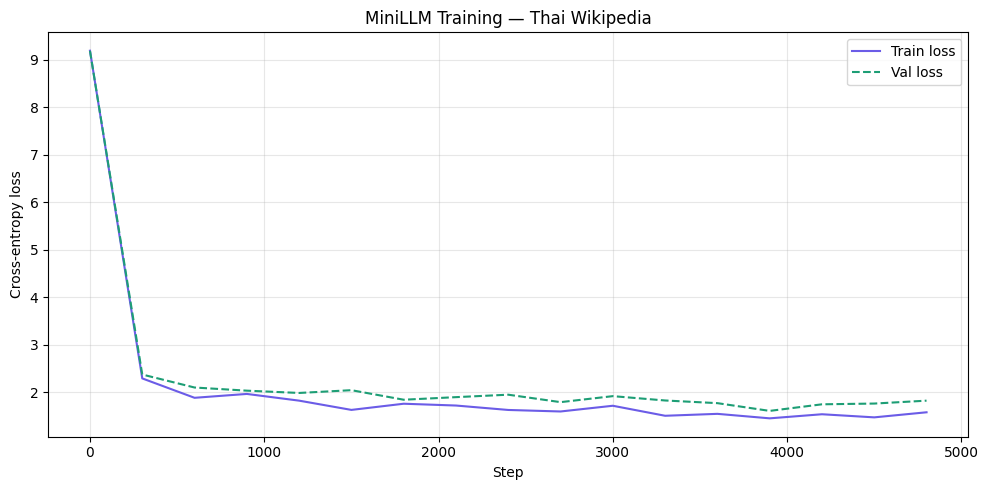

Final val loss: 1.820
Perplexity:     6.2


In [39]:
# Plot loss curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["step"], history["train_loss"], label="Train loss", color="#6B5CE7")
ax.plot(history["step"], history["val_loss"],   label="Val loss",   color="#1D9E75", linestyle="--")
ax.set_xlabel("Step"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("MiniLLM Training — Thai Wikipedia")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=100)
plt.show()

final_val = history["val_loss"][-1]
print(f"Final val loss: {final_val:.3f}")
print(f"Perplexity:     {math.exp(final_val):.1f}")


## 8.7 Generate Thai Text

In [40]:
model.eval()

for seed_text, temp in [
    ("การประยุกต์ใช้ AI", 0.5),
    ("โรงพยาบาล",         0.8),
    ("การเรียนรู้",         1.0),
    ("การประยุกต์ใช้ AI", 1.5),
]:
    seed_ids = torch.tensor([[stoi.get(c, 0) for c in seed_text]], dtype=torch.long).to(DEVICE)
    out      = model.generate(seed_ids, max_new_tokens=120, temperature=temp, top_k=40)
    sample   = decode(out[0].tolist())
    print(f"\n[temp={temp}] Seed: '{seed_text}'")
    print(f"  {sample[:150]}")


[temp=0.5] Seed: 'การประยุกต์ใช้ AI'
  การประยุกต์ใช้ AI Linternation Reforment Line Marting Row และ Ander Champ (AAT) และ The Sour ซึ่งเป็นการแข่งขัน เมื่อ 20 ปี โดยมีสายการบิ

[temp=0.8] Seed: 'โรงพยาบาล'
  โรงพยาบาล คณะรัฐมนตรี เนื่องจากการจำแนกถูกกล่าวหาว่ารัฐบาลจากเวียดนามที่มีการประสบการณ์ทั้งหมด พบผู้การออกมาอีกครั้งในปี พ.ศ. 254

[temp=1.0] Seed: 'การเรียนรู้'
  การเรียนรู้ร่วมกับหงสนูศิราษ้าว่า ขณะที่มีปลาอิสราเอลได้นานเดียวได้สามารถใช้ ผ็อกกระตู้ที่เขาคุณแสงออกจากการถ่ายภาพเนื้อจะออกมาสมปร

[temp=1.5] Seed: 'การประยุกต์ใช้ AI'
  การประยุกต์ใช้ AIE ที่ตั้งอาจมีฉากหกสม้าโปรใน ค.ศ. 2005 สำหรับ สหภาพบูลเกิด น่านสังหาร
บริะเข้ใช้ TCKO ร่วมกันในชื่อ Taatzrian Darsotssih


## 8.8 Architecture Experiment Lab 🧪

**Instructions:** Change ONE parameter at a time, train 500 steps, compare val loss.

| Experiment | Parameter to change |
|------------|---------------------|
| A (baseline) | Default config |
| B | Replace SwiGLU with ReLU FFN |
| C | Remove positional encoding (no RoPE) |
| D | Use 1 attention head instead of 8 |


In [41]:
EXPERIMENT_STEPS = 500   # short runs for comparison

def run_experiment(name, model_override=None, steps=EXPERIMENT_STEPS):
    print(f"\n{'─'*50}")
    print(f"Experiment: {name}")
    if model_override is None:
        m = MiniLLM(vocab_size=VOCAB_SIZE, d_model=256, n_layers=4, n_heads=8)
    else:
        m = model_override
    params = sum(p.numel() for p in m.parameters())
    print(f"Parameters: {params:,}")
    h = train(m, steps=steps, block_size=128, batch_size=32, eval_every=steps)
    final = h["val_loss"][-1]

    m.eval()
    # Fix: Move seed tensor to the correct device (GPU)
    seed = torch.tensor([[stoi.get(c, 0) for c in "การเรียน"]], dtype=torch.long).to(DEVICE)
    out  = m.generate(seed, max_new_tokens=60, temperature=0.8, top_k=40)
    print(f"Sample: {decode(out[0].tolist())[:80]}")
    return final


results = {}

# ── Exp A: Baseline (SwiGLU + RoPE + 8 heads) ──
results["A_baseline"] = run_experiment("A: Baseline (SwiGLU + RoPE + 8 heads)")

# ── Exp B: Replace SwiGLU with simple ReLU FFN ──
class SimpleFFN(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model, bias=False),
            nn.ReLU(),
            nn.Linear(4 * d_model, d_model, bias=False),
        )
    def forward(self, x): return self.net(x)

model_b = MiniLLM(vocab_size=VOCAB_SIZE, d_model=256, n_layers=4, n_heads=8)
for block in model_b.blocks:
    block.ffn = SimpleFFN(256)
results["B_relu_ffn"] = run_experiment("B: ReLU FFN (no SwiGLU)", model_override=model_b)

# ── Exp C: No positional encoding (skip RoPE) ──
class MHANoRoPE(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.d_model = d_model
        self.W_qkv   = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_o     = nn.Linear(d_model, d_model,     bias=False)
        self.drop    = nn.Dropout(dropout)

    def forward(self, x, cos=None, sin=None):
        B, T, C = x.shape
        Q, K, V = self.W_qkv(x).chunk(3, dim=-1)
        def sh(t): return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = sh(Q), sh(K), sh(V)
        out = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
        return self.W_o(out.transpose(1,2).contiguous().view(B, T, self.d_model))

model_c = MiniLLM(vocab_size=VOCAB_SIZE, d_model=256, n_layers=4, n_heads=8)
for block in model_c.blocks:
    block.attn = MHANoRoPE(256, 8)
results["C_no_rope"] = run_experiment("C: No positional encoding", model_override=model_c)

# ── Summary ──
print("\n" + "=" * 50)
print("EXPERIMENT RESULTS")
print("=" * 50)
for name, val_loss in results.items():
    bar = "█" * int((5.0 - val_loss) * 10)
    print(f"  {name:<22} val_loss={val_loss:.3f}  {bar}")

best = min(results, key=results.get)
print(f"\n🏆 Best: {best} (val_loss={results[best]:.3f})")


──────────────────────────────────────────────────
Experiment: A: Baseline (SwiGLU + RoPE + 8 heads)
Parameters: 5,723,904
step     0 | train 9.238 | val 9.240 | 0s
step   500 | train 2.239 | val 2.254 | 34s
Sample: การเรียนการนำออกเปลี่ยนเก่า ทำให้มีการละตามคำไพรักษรคือ ในค้ามาชิกษู

──────────────────────────────────────────────────
Experiment: B: ReLU FFN (no SwiGLU)
Parameters: 5,658,368
step     0 | train 9.185 | val 9.208 | 0s
step   500 | train 2.158 | val 2.372 | 32s
Sample: การเรียน จากรอร์เหนือว่าต้านคนที่รับแมน มีเองและอ้างตำแหน่งของพื้นตั

──────────────────────────────────────────────────
Experiment: C: No positional encoding
Parameters: 5,723,904
step     0 | train 9.300 | val 9.297 | 0s
step   500 | train 3.037 | val 3.178 | 32s
Sample: การเรียน 65 10 พรงเที่คณายต่ายนศ เวั้สาลังวหน ที่งจัง อมาชิกร้แลดนิเ

EXPERIMENT RESULTS
  A_baseline             val_loss=2.254  ███████████████████████████
  B_relu_ffn             val_loss=2.372  ██████████████████████████
  C_no_rope

---
## Module 9 — Vision Transformer (ViT) Concepts

### 9.1 How ViT Works

Key insight: treat an image as a **sequence of patches** — exactly like tokens. Run a standard transformer on the patches.

```
224×224 image → 196 patches of 16×16 pixels → flatten → project to d_model → Transformer
```


In [42]:
class VisionTransformer(nn.Module):
    """
    Minimal ViT-Base implementation.
    img_size=224, patch_size=16 → 196 patches.
    """
    def __init__(self, img_size=224, patch_size=16, in_channels=3,
                 d_model=768, n_layers=12, n_heads=12, n_classes=1000):
        super().__init__()
        assert img_size % patch_size == 0
        n_patches = (img_size // patch_size) ** 2    # 196
        patch_dim = in_channels * patch_size ** 2    # 3 × 16 × 16 = 768

        self.d_model = d_model
        self.n_heads = n_heads

        # Patch embedding: flatten + linear projection
        self.patch_embed = nn.Sequential(
            nn.LayerNorm(patch_dim),
            nn.Linear(patch_dim, d_model, bias=False),
            nn.LayerNorm(d_model),
        )
        # Learnable [CLS] token whose final state represents the whole image
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)

        # Learned positional embeddings (one per patch + CLS)
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        nn.init.normal_(self.pos_embed, std=0.02)

        # Encoder blocks (note: no causal mask — encoder, not decoder)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout=0.0)
            for _ in range(n_layers)
        ])
        self.norm = RMSNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def patchify(self, img):
        """img: (B, C, H, W) → (B, n_patches, patch_dim)"""
        B, C, H, W = img.shape
        P = 16
        img = img.reshape(B, C, H//P, P, W//P, P)
        img = img.permute(0, 2, 4, 1, 3, 5)   # (B, nH, nW, C, P, P)
        return img.reshape(B, (H//P)*(W//P), C*P*P)

    def forward(self, img):
        B = img.shape[0]
        patches = self.patchify(img)            # (B, 196, 768)
        x       = self.patch_embed(patches)     # (B, 196, d_model)
        cls     = self.cls_token.expand(B, -1, -1)
        x       = torch.cat([cls, x], dim=1)   # (B, 197, d_model)
        x       = x + self.pos_embed

        # Encoder (uses fake cos/sin since ViT uses learned absolute pos)
        # Fix: Access d_model and n_heads as self.d_model and self.n_heads
        cos_v, sin_v = precompute_rope_freqs(self.d_model // self.n_heads, x.shape[1])
        n_heads_v = 12
        cos_v, sin_v = precompute_rope_freqs(self.d_model // n_heads_v, x.shape[1])
        for block in self.blocks:
            x = block(x, cos_v, sin_v)

        return self.head(self.norm(x[:, 0]))    # CLS token output


# Test ViT-Base
vit = VisionTransformer(img_size=224, patch_size=16, d_model=768, n_layers=12, n_heads=12)
img = torch.randn(2, 3, 224, 224)   # 2 images, RGB, 224×224
out = vit(img)
print(f"ViT input:  {img.shape}")
print(f"ViT output: {out.shape}   ← class logits ✓")
count_params(vit)

# Show patch dimensions
patches = vit.patchify(img)
print(f"\nPatches: {patches.shape}")
print(f"  Batch={patches.shape[0]}, n_patches={patches.shape[1]}, patch_dim={patches.shape[2]}")
print(f"  ({224//16})² = {(224//16)**2} patches per image ✓")

ViT input:  torch.Size([2, 3, 224, 224])
ViT output: torch.Size([2, 1000])   ← class logits ✓
Total parameters:  86,467,816
Model size (fp32):    345.9 MB
Model size (bf16):    172.9 MB

Patches: torch.Size([2, 196, 768])
  Batch=2, n_patches=196, patch_dim=768
  (14)² = 196 patches per image ✓


### 9.2 LLaVA-Style Multimodal Projector

Bridges ViT visual features → LLM text embedding space.

In [43]:
class LLaVAProjector(nn.Module):
    """Projects ViT features into LLM embedding space (2-layer MLP)."""
    def __init__(self, vit_dim=768, llm_dim=4096):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(vit_dim, llm_dim, bias=False),
            nn.GELU(),
            nn.Linear(llm_dim, llm_dim, bias=False),
        )
    def forward(self, vit_features):
        return self.proj(vit_features)  # (B, n_patches, llm_dim)


projector = LLaVAProjector(vit_dim=768, llm_dim=4096)
vit_feats = torch.randn(1, 196, 768)   # 196 image patches
projected = projector(vit_feats)
print(f"ViT features → projected: {vit_feats.shape} → {projected.shape}")
print(f"These 196 vectors are inserted into the LLM's token sequence ✓")
print(f"\nProjector params: {sum(p.numel() for p in projector.parameters()):,}")


ViT features → projected: torch.Size([1, 196, 768]) → torch.Size([1, 196, 4096])
These 196 vectors are inserted into the LLM's token sequence ✓

Projector params: 19,922,944


---
## 📊 Architecture Comparison Table

| Component | Original 2017 | GPT-2 (2019) | Llama 4 / Typhoon 2 (2025) |
|-----------|--------------|--------------|---------------------------|
| Norm | LayerNorm (post) | LayerNorm (post) | **RMSNorm (pre)** ← we used this |
| Activation | ReLU | GeLU | **SwiGLU** ← we used this |
| Positional | Sinusoidal fixed | Learned absolute | **RoPE** ← we used this |
| Attention | MHA | MHA | MHA + FlashAttention + GQA |
| Expert routing | None | None | MoE (Llama 4 Scout) |
| Context | 512 tokens | 1024 tokens | 128k–10M tokens |

### 🎉 What you built today

You implemented every component in the **Llama 4 / Typhoon 2 style** architecture — just at smaller scale.


In [44]:
# Final parameter count summary
print("=" * 50)
print("WHAT YOU BUILT TODAY")
print("=" * 50)

components = {
    "RMSNorm":             RMSNorm(256),
    "SwiGLU FFN":          SwiGLU(256),
    "MultiHeadAttention":  MultiHeadAttention(256, 8),
    "TransformerBlock":    TransformerBlock(256, 8),
    "MiniLLM (6 layers)":  MiniLLM(VOCAB_SIZE, 256, 6, 8),
    "ViT-Base (12 layers)":VisionTransformer(),
    "LLaVA Projector":     LLaVAProjector(),
}

for name, module in components.items():
    p = sum(m.numel() for m in module.parameters())
    print(f"  {name:<28} {p:>12,} parameters")

print("\n✅ All components implemented from scratch!")
print("✅ MiniLLM trained on Thai text!")


WHAT YOU BUILT TODAY
  RMSNorm                               256 parameters
  SwiGLU FFN                        540,672 parameters
  MultiHeadAttention                262,144 parameters
  TransformerBlock                  803,328 parameters
  MiniLLM (6 layers)              7,330,560 parameters
  ViT-Base (12 layers)           86,467,816 parameters
  LLaVA Projector                19,922,944 parameters

✅ All components implemented from scratch!
✅ MiniLLM trained on Thai text!
